# MJO Composites for October year (1980-2025)=>

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os

# =====================================================
# PATHS
# =====================================================

csv_file = r"D:\PHD 2025~\PHD\MJO_Index_1.csv"
anom_dir = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS"
output_dir = r"D:\PHD 2025~\PHD\1.MJO Composites"

os.makedirs(output_dir, exist_ok=True)

# =====================================================
# LOAD CSV
# =====================================================

df = pd.read_csv(csv_file)
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# =====================================================
# LOAD ALL FILES (ONCE)
# =====================================================

file_list = sorted([
    os.path.join(anom_dir, f)
    for f in os.listdir(anom_dir)
    if f.endswith(".nc")
])

print(f"📂 Found {len(file_list)} yearly files")

ds = xr.open_mfdataset(
    file_list,
    combine="by_coords"   # 🔥 IMPORTANT CHANGE
)

# Fix dimension order if needed
ds = ds.transpose("time", "latitude", "longitude")

print(ds)

# =====================================================
# LOOP THROUGH 8 PHASES
# =====================================================

for phase in range(1, 9):

    print(f"\nProcessing Phase {phase}...")

    df_phase = df[
        (df["phase"] == phase) &
        (df["amplitude"] >= 1)
    ]

    if df_phase.empty:
        print(f"❌ No dates found")
        continue

    phase_dates = df_phase["date"].values

    # =====================================================
    # SELECT ONLY REQUIRED DATES
    # =====================================================

    available_dates = np.intersect1d(ds["time"].values, phase_dates)

    if len(available_dates) == 0:
        print(f"❌ No matching dates in dataset")
        continue

    print(f"✅ Using {len(available_dates)} days")

    ds_sel = ds.sel(time=available_dates)

    # =====================================================
    # COMPOSITE
    # =====================================================

    comp = ds_sel["tp_mjo"].mean(dim="time")

    comp_ds = comp.to_dataset(name="tp_mjo_composite")

    comp_ds["tp_mjo_composite"].attrs["description"] = f"MJO Phase {phase} Composite (Amp >=1)"
    comp_ds["tp_mjo_composite"].attrs["units"] = "same as input"

    # =====================================================
    # SAVE
    # =====================================================

    output_file = os.path.join(output_dir, f"MJO_Phase_{phase}_Composite.nc")
    comp_ds.to_netcdf(output_file)

    print(f"💾 Saved: {output_file}")

print("\n🎉 Done!")

📂 Found 46 yearly files
<xarray.Dataset> Size: 393MB
Dimensions:    (latitude: 501, longitude: 801, time: 245)
Coordinates:
  * latitude   (latitude) float64 4kB 50.0 49.9 49.8 49.7 ... 0.3 0.2 0.1 0.0
  * longitude  (longitude) float64 6kB 40.0 40.1 40.2 40.3 ... 119.8 119.9 120.0
  * time       (time) datetime64[ns] 2kB 2000-03-01 2000-03-02 ... 2000-10-31
    expver     (time) <U4 4kB dask.array<chunksize=(245,), meta=np.ndarray>
    number     int64 8B ...
Data variables:
    tp_mjo     (time, latitude, longitude) float32 393MB dask.array<chunksize=(245, 501, 801), meta=np.ndarray>

Processing Phase 1...
❌ No matching dates in dataset

Processing Phase 2...
✅ Using 2 days
💾 Saved: D:\PHD 2025~\PHD\1.MJO Composites\MJO_Phase_2_Composite.nc

Processing Phase 3...
✅ Using 3 days
💾 Saved: D:\PHD 2025~\PHD\1.MJO Composites\MJO_Phase_3_Composite.nc

Processing Phase 4...
✅ Using 2 days
💾 Saved: D:\PHD 2025~\PHD\1.MJO Composites\MJO_Phase_4_Composite.nc

Processing Phase 5...
✅ Using 16 d

# MJO Composites for October 2025 only=>

In [3]:
import xarray as xr
import pandas as pd
import os

# =====================================================
# PATHS
# =====================================================

csv_file = r"D:\PHD 2025~\PHD\MJO_Index_1.csv"
data_file = r"D:\PHD 2025~\PHD\6.MJO_FILTER\06_MJO_LANCZOS\mjo_anom_ERA5_Land_Rainfall_2025.nc"

output_dir = r"D:\PHD 2025~\PHD\2.MJO Composites 2025"
os.makedirs(output_dir, exist_ok=True)

# =====================================================
# LOAD CSV
# =====================================================

df = pd.read_csv(csv_file)
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# =====================================================
# FILTER ONLY OCT 2025
# =====================================================

df_oct = df[
    (df["year"] == 2025) &
    (df["month"] == 10)
]

# Create (month, day) columns
df_oct["month"] = df_oct["date"].dt.month
df_oct["day"]   = df_oct["date"].dt.day

# =====================================================
# LOAD DATASET
# =====================================================

print("📂 Loading dataset...")
ds = xr.open_dataset(data_file)

ds = ds.transpose("time", "latitude", "longitude")

# Convert time
ds["time"] = pd.to_datetime(ds["time"].values)

# Extract month and day from dataset
ds["month"] = ds["time"].dt.month
ds["day"]   = ds["time"].dt.day

print(ds)

# =====================================================
# LOOP THROUGH PHASES
# =====================================================

for phase in range(1, 9):

    print(f"\nProcessing Phase {phase} (Oct 2025)...")

    df_phase = df_oct[
        (df_oct["phase"] == phase) &
        (df_oct["amplitude"] >= 1)
    ]

    if df_phase.empty:
        print(f"❌ No dates found")
        continue

    # Create list of (month, day) tuples
    md_list = list(zip(df_phase["month"], df_phase["day"]))

    # =====================================================
    # MATCH USING MONTH + DAY
    # =====================================================

    mask = [(m, d) in md_list for m, d in zip(ds["month"].values, ds["day"].values)]

    ds_sel = ds.isel(time=mask)

    if ds_sel.time.size == 0:
        print("❌ No matching dates in dataset")
        continue

    print(f"✅ Using {ds_sel.time.size} days")

    # =====================================================
    # COMPOSITE
    # =====================================================

    comp = ds_sel["tp_mjo"].mean(dim="time")

    comp_ds = comp.to_dataset(name="tp_mjo_composite")

    comp_ds["tp_mjo_composite"].attrs["description"] = f"MJO Phase {phase} Composite (Oct 2025)"
    comp_ds["tp_mjo_composite"].attrs["units"] = "same as input"

    # =====================================================
    # SAVE
    # =====================================================

    output_file = os.path.join(output_dir, f"MJO_Phase_{phase}_Composite_2025.nc")

    comp_ds.to_netcdf(output_file)

    print(f"💾 Saved: {output_file}")

print("\n🎉 Done!")

📂 Loading dataset...
<xarray.Dataset> Size: 393MB
Dimensions:    (time: 245, latitude: 501, longitude: 801)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2000-03-01 2000-03-02 ... 2000-10-31
    expver     (time) <U4 4kB ...
  * latitude   (latitude) float64 4kB 50.0 49.9 49.8 49.7 ... 0.3 0.2 0.1 0.0
  * longitude  (longitude) float64 6kB 40.0 40.1 40.2 40.3 ... 119.8 119.9 120.0
    number     int64 8B ...
Data variables:
    tp_mjo     (time, latitude, longitude) float32 393MB ...
    month      (time) int64 2kB 3 3 3 3 3 3 3 3 3 ... 10 10 10 10 10 10 10 10 10
    day        (time) int64 2kB 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30 31

Processing Phase 1 (Oct 2025)...
✅ Using 4 days
💾 Saved: D:\PHD 2025~\PHD\2.MJO Composites 2025\MJO_Phase_1_Composite_2025.nc

Processing Phase 2 (Oct 2025)...
✅ Using 5 days
💾 Saved: D:\PHD 2025~\PHD\2.MJO Composites 2025\MJO_Phase_2_Composite_2025.nc

Processing Phase 3 (Oct 2025)...
✅ Using 3 days
💾 Saved: D:\PHD 2025~\PHD\2.MJO Compos

Available phases: [1, 2, 3, 4, 5, 6]


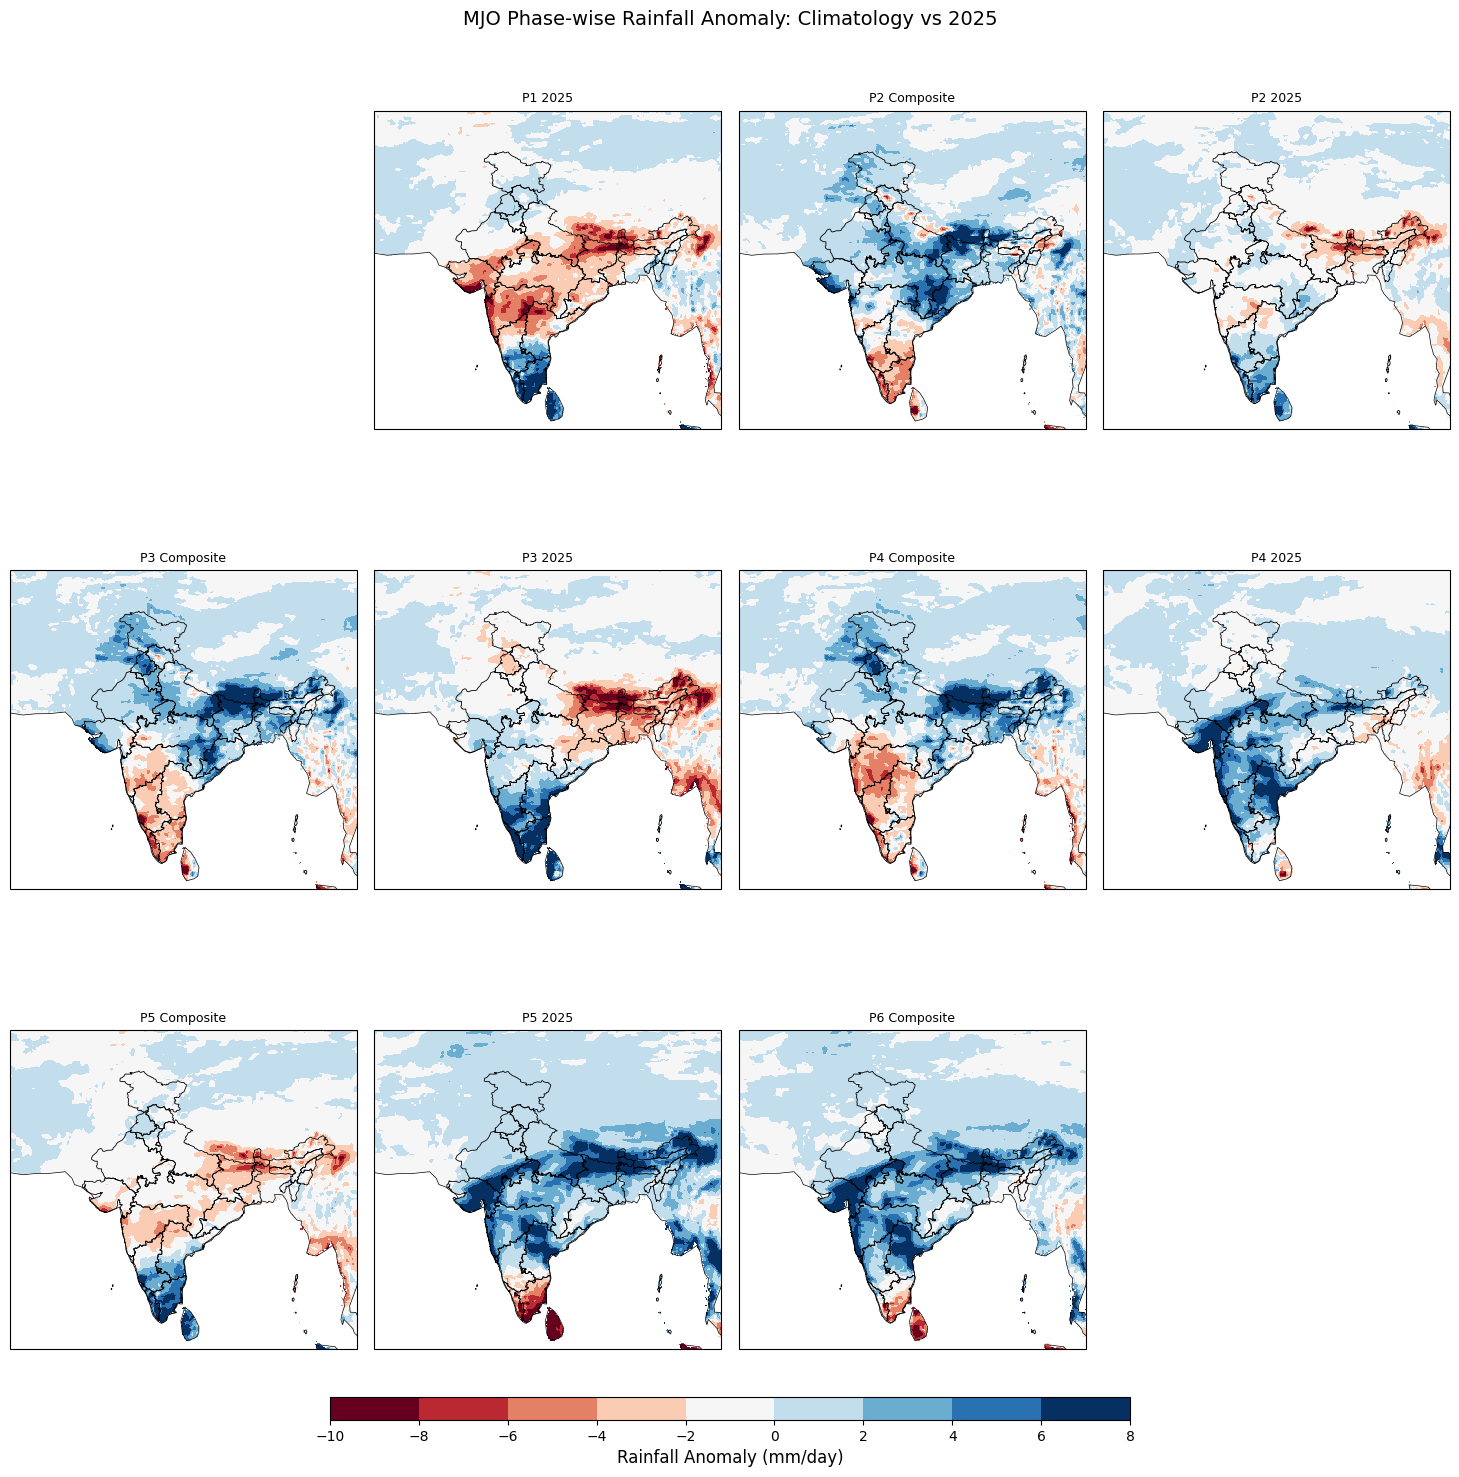

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import os
import math

# =====================================================
# PATHS
# =====================================================

clim_dir = r"D:\PHD 2025~\PHD\1.MJO Composites"
comp2025_dir = r"D:\PHD 2025~\PHD\2.MJO Composites 2025"

india_shp = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# =====================================================
# COLORMAP
# =====================================================

levels = range(-10, 10, 2)
cmap = plt.cm.RdBu
norm = mcolors.BoundaryNorm(levels, cmap.N)

# =====================================================
# FIND AVAILABLE PHASES
# =====================================================

available_phases = []

for phase in range(1, 9):
    clim_file = os.path.join(clim_dir, f"MJO_Phase_{phase}_Composite.nc")
    comp_file = os.path.join(comp2025_dir, f"MJO_Phase_{phase}_Composite_2025.nc")

    if os.path.exists(clim_file) or os.path.exists(comp_file):
        available_phases.append(phase)

if len(available_phases) == 0:
    raise ValueError("❌ No phase files found!")

print("Available phases:", available_phases)

# =====================================================
# GRID SETTINGS
# =====================================================

n_phases = len(available_phases)
n_phase_cols = 2
n_rows = math.ceil(n_phases / n_phase_cols)
total_cols = n_phase_cols * 2

fig = plt.figure(figsize=(16, 5 * n_rows))
proj = ccrs.PlateCarree()

shape_feature = cfeature.ShapelyFeature(
    shpreader.Reader(india_shp).geometries(),
    proj,
    edgecolor="black",
    facecolor="none",
    linewidth=0.6
)

# =====================================================
# LOOP THROUGH PHASES
# =====================================================

for i, phase in enumerate(available_phases):

    row = i // n_phase_cols
    col_block = i % n_phase_cols
    base_col = col_block * 2

    # -------------------------
    # CLIMATOLOGY
    # -------------------------
    clim_file = os.path.join(clim_dir, f"MJO_Phase_{phase}_Composite.nc")

    if os.path.exists(clim_file):
        ds_clim = xr.open_dataset(clim_file)

        # 🔥 UPDATED VARIABLE NAME
        data_clim = ds_clim["tp_mjo_composite"]

        ax1 = plt.subplot(
            n_rows, total_cols,
            row * total_cols + base_col + 1,
            projection=proj
        )

        plot = ax1.pcolormesh(
            data_clim.longitude,
            data_clim.latitude,
            data_clim,
            cmap=cmap,
            norm=norm,
            shading="auto"
        )

        ax1.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.5)
        ax1.add_feature(shape_feature)
        ax1.set_extent([60, 100, 5, 40])

        ax1.set_title(f"P{phase} Composite", fontsize=9)

    # -------------------------
    # 2025
    # -------------------------
    comp_file = os.path.join(comp2025_dir, f"MJO_Phase_{phase}_Composite_2025.nc")

    if os.path.exists(comp_file):
        ds_2025 = xr.open_dataset(comp_file)

        # 🔥 UPDATED VARIABLE NAME
        data_2025 = ds_2025["tp_mjo_composite"]

        ax2 = plt.subplot(
            n_rows, total_cols,
            row * total_cols + base_col + 2,
            projection=proj
        )

        plot = ax2.pcolormesh(
            data_2025.longitude,
            data_2025.latitude,
            data_2025,
            cmap=cmap,
            norm=norm,
            shading="auto"
        )

        ax2.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.5)
        ax2.add_feature(shape_feature)
        ax2.set_extent([60, 100, 5, 40])

        ax2.set_title(f"P{phase} 2025", fontsize=9)

# =====================================================
# COLORBAR
# =====================================================

cax = fig.add_axes([0.25, 0.04, 0.5, 0.015])

cbar = fig.colorbar(plot, cax=cax, orientation="horizontal")
cbar.set_label("Rainfall Anomaly (mm/day)", fontsize=12)

# =====================================================
# SPACING
# =====================================================

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.92,
    bottom=0.08,
    wspace=0.05,
    hspace=0.35
)

plt.suptitle(
    "MJO Phase-wise Rainfall Anomaly: Climatology vs 2025",
    fontsize=14
)

plt.show()

# I think whole thing is wrong!!!! Cuz of ERA land data